In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('tested.csv')

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [8]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


df["Age"] = df["Age"].fillna(df["Age"].median())


X = df[["Pclass", "Age"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual keys:", y_test.values)


Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1
 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1]
Actual keys: [0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1
 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0
 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0]


In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[74 11]
 [36  5]]


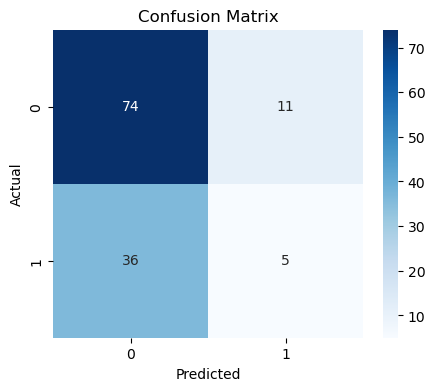

In [12]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

0.626984126984127


In [14]:
from sklearn.metrics import precision_score

precision = precision_score(

    y_test,

    y_pred

)

print(precision)

0.3125


In [15]:
from sklearn.metrics import recall_score

recall = recall_score(

    y_test,

    y_pred

)

print(recall)

0.12195121951219512


In [16]:
from sklearn.metrics import f1_score

f1 = f1_score(

    y_test,

    y_pred

)

print(f1)

0.17543859649122806


In [17]:
probability = model.predict_proba(X_test)

print(probability)

[[0.68698802 0.31301198]
 [0.50443646 0.49556354]
 [0.68414576 0.31585424]
 [0.69403218 0.30596782]
 [0.69473171 0.30526829]
 [0.61330931 0.38669069]
 [0.68981629 0.31018371]
 [0.51267461 0.48732539]
 [0.5888126  0.4111874 ]
 [0.68840391 0.31159609]
 [0.68414576 0.31585424]
 [0.51432156 0.48567844]
 [0.68057351 0.31942649]
 [0.50443646 0.49556354]
 [0.68840391 0.31159609]
 [0.68840391 0.31159609]
 [0.68911054 0.31088946]
 [0.51761449 0.48238551]
 [0.67625867 0.32374133]
 [0.59200112 0.40799888]
 [0.61876708 0.38123292]
 [0.50608443 0.49391557]
 [0.67118659 0.32881341]
 [0.5975623  0.4024377 ]
 [0.68840391 0.31159609]
 [0.68236232 0.31763768]
 [0.4929     0.5071    ]
 [0.49454789 0.50545211]
 [0.69682489 0.30317511]
 [0.5975623  0.4024377 ]
 [0.69192823 0.30807177]
 [0.68485763 0.31514237]
 [0.49949212 0.50050788]
 [0.68840391 0.31159609]
 [0.59120471 0.40879529]
 [0.5935925  0.4064075 ]
 [0.68627876 0.31372124]
 [0.59518192 0.40481808]
 [0.59676934 0.40323066]
 [0.49908009 0.50091991]


In [18]:
from sklearn.metrics import roc_curve

from sklearn.metrics import auc

In [19]:
probability = model.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(

    y_test,

    probability

)

roc_auc = auc(

    fpr,

    tpr

)

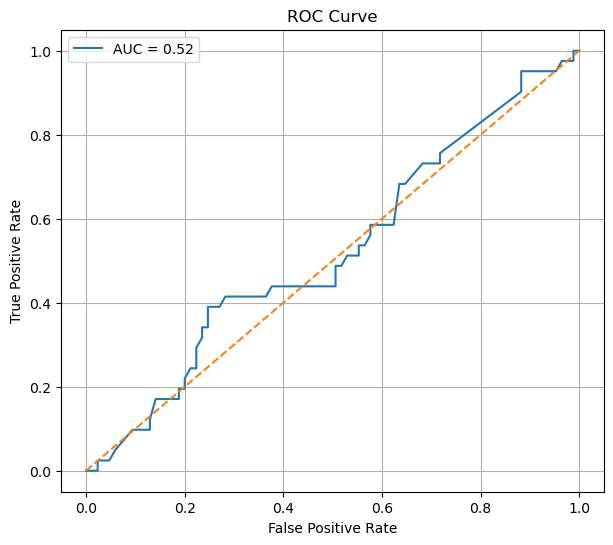

In [20]:
plt.figure(figsize=(7,6))
plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.2f}"

)

plt.plot(

    [0,1],

    [0,1],

    '--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()